In [6]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

In [7]:
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import mannwhitneyu, wilcoxon, spearmanr
from scipy.optimize import linear_sum_assignment
from statsmodels.stats.multitest import multipletests

from imports import *
from config import dir_config
from src.shared_glm_hmm.grouping import session_metadata

In [8]:
processed_dir = Path(dir_config.data.processed)
model_dir = (processed_dir / "glm_hmm"
             / "standardized_stimulus_with_color_no_prev_coh__globaL_pooled_cv")

metadata = pd.read_csv(processed_dir / "processed_metadata_all_data_accu_60.csv")
sess_md  = session_metadata(metadata).set_index("session_id")

# UPDRS per session (OFF session scores for PD)
updrs_cols = ["subject_id", "session_id", "UPDRS", "tremor_score", "bradykinesia_score",
              "UPDRS_improvement", "tremor_improvement", "bradykinesia_improvement"]
updrs_md = metadata[[c for c in updrs_cols if c in metadata.columns]].copy()

GROUPS = ["asmHC", "Tremor_OFF", "Brady_OFF", "Tremor_ON", "Brady_ON"]
GROUP_LABELS = {
    "asmHC": "HC", "Tremor_OFF": "Tremor OFF", "Brady_OFF": "Brady OFF",
    "Tremor_ON": "Tremor ON", "Brady_ON": "Brady ON",
}
FEATS = ["stimulus", "color", "bias", "prev_choice_1", "prev_choice_coherence_1"]
STIM_IDX  = FEATS.index("stimulus")
COLOR_IDX = FEATS.index("color")

# Lapse threshold: states with stimulus weight below this are "low-engagement"
LAPSE_THRESHOLD = 2.0

print("Model dir:", model_dir)
print("UPDRS columns:", [c for c in updrs_cols if c in metadata.columns])

Model dir: /mnt/pd-data/processed/glm_hmm/standardized_stimulus_with_color_no_prev_coh__globaL_pooled_cv
UPDRS columns: ['subject_id', 'session_id', 'UPDRS', 'tremor_score', 'bradykinesia_score', 'UPDRS_improvement', 'tremor_improvement', 'bradykinesia_improvement']


## 1. Sanity check: Tremor-OFF K=2 vs K=3

CV selected K=2 for Tremor-OFF, but the CV LL curve is still improving at K=5.
Before committing to "Tremor-OFF has a simpler architecture than HC/Tremor-ON (K=3)",
we check whether the K=3 model adds a genuinely distinct third state or just
splits an existing one with near-zero occupancy.

**Interpretation 1 (simpler architecture):** third state has near-zero occupancy or
weights nearly identical to another state.

**Interpretation 2 (power/noise):** third state has meaningful occupancy and
distinct weights — it exists but CV couldn't confirm it with n≈11 sessions.

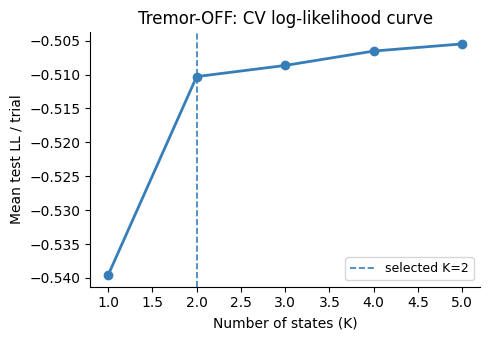

CV LL per K (Tremor-OFF): {1: -0.53958, 2: -0.5103, 3: -0.50865, 4: -0.50653, 5: -0.50548}


In [9]:
def _align(w, ref):
    cost = np.array([[np.sum((w[i]-ref[j])**2) for j in range(len(ref))] for i in range(len(w))])
    _, col = linear_sum_assignment(cost)
    inv = np.empty_like(col); inv[col] = np.arange(len(col))
    return inv


def load_final(group):
    """Load the final (best-k) bundle for a group."""
    return pickle.load(open(model_dir / f"{group}_final.pkl", "rb"))


def load_cv(group):
    """Load the CV bundle (all K fits) for a group."""
    return pickle.load(open(model_dir / f"{group}.pkl", "rb"))


# ── CV LL curve ───────────────────────────────────────────────────────────────
toff_cv = load_cv("Tremor_OFF")
gpcv = toff_cv["group_pooled_cv"]
sr   = gpcv["state_range"]                          # [1..5]
tll  = np.array(gpcv["test_ll"])                    # (K, folds)
nt   = np.array(gpcv["n_test_trials"])              # (K, folds)
norm_ll = (tll / nt).mean(axis=1)                   # mean bits/trial per K

fig, ax = plt.subplots(figsize=(5, 3.5))
ax.plot(sr, norm_ll, "o-", lw=2, color="#377eb8")
ax.axvline(2, color="#377eb8", ls="--", lw=1.2, label="selected K=2")
ax.set(xlabel="Number of states (K)", ylabel="Mean test LL / trial",
       title="Tremor-OFF: CV log-likelihood curve")
ax.legend(fontsize=9)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout(); plt.show()

print("CV LL per K (Tremor-OFF):",
      dict(zip(sr.tolist(), np.round(norm_ll, 5).tolist())))

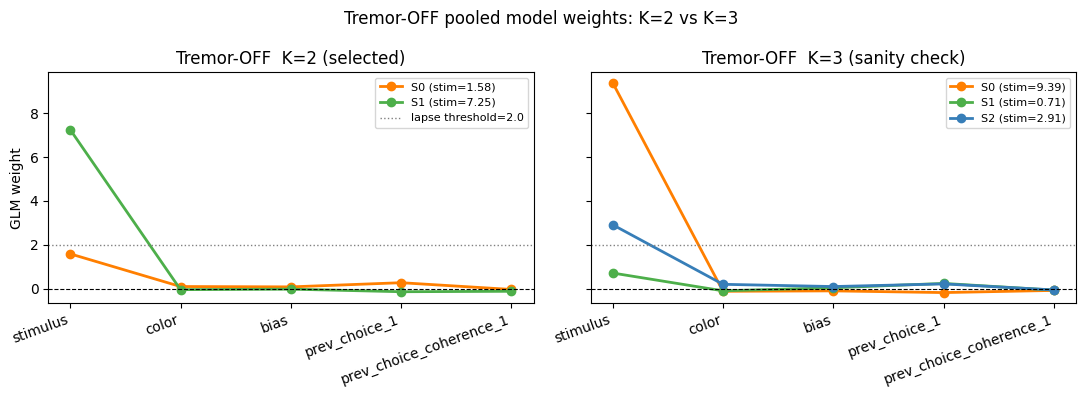


K=2 pooled weights:
    stimulus  color   bias  prev_choice_1  prev_choice_coherence_1
S0     1.582  0.091  0.074          0.265                   -0.043
S1     7.252 -0.052 -0.029         -0.147                   -0.126

K=3 pooled weights (best init):
    stimulus  color   bias  prev_choice_1  prev_choice_coherence_1
S0     9.389 -0.126 -0.107         -0.185                   -0.086
S1     0.707 -0.106  0.034          0.233                   -0.072
S2     2.909  0.192  0.090          0.211                   -0.066


In [10]:
# ── K=2 weights (from final bundle) ──────────────────────────────────────────
toff_final = load_final("Tremor_OFF")
w2 = -toff_final["model"]["pooled"].observations.params[:, 0, :]   # (2, M)

# ── K=3 weights: pick best init by training LL ───────────────────────────────
k3_inits = gpcv["models"][3]   # list of 5 HMM objects (one per initialization)
data_toff = toff_cv["data"]    # {session_id: DataFrame}

def session_log_likelihood(model, df):
    obs  = df["choices"].values.astype(int).reshape(-1, 1)
    inp  = df[FEATS].values.astype(float)
    msk  = df["mask"].values.astype(bool).reshape(-1, 1)
    return model.log_likelihood(obs, inputs=inp, masks=msk)

def total_ll(model, data_dict):
    return sum(session_log_likelihood(model, df) for df in data_dict.values())

best_ll  = -np.inf
best_k3  = None
for init in k3_inits:
    ll = total_ll(init, data_toff)
    if ll > best_ll:
        best_ll, best_k3 = ll, init

w3 = -best_k3.observations.params[:, 0, :]   # (3, M) best-init K=3

# ── Side-by-side weight comparison ───────────────────────────────────────────
x = np.arange(len(FEATS))
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
colors2 = ["#ff7f00", "#4daf4a"]
colors3 = ["#ff7f00", "#4daf4a", "#377eb8"]

for k in range(2):
    axes[0].plot(x, w2[k], "o-", color=colors2[k], lw=2, label=f"S{k} (stim={w2[k,STIM_IDX]:.2f})")
axes[0].axhline(0, color="k", ls="--", lw=0.8)
axes[0].axhline(LAPSE_THRESHOLD, color="gray", ls=":", lw=1, label=f"lapse threshold={LAPSE_THRESHOLD}")
axes[0].set_xticks(x); axes[0].set_xticklabels(FEATS, rotation=20, ha="right")
axes[0].set(ylabel="GLM weight", title="Tremor-OFF  K=2 (selected)")
axes[0].legend(fontsize=8)

for k in range(3):
    axes[1].plot(x, w3[k], "o-", color=colors3[k], lw=2, label=f"S{k} (stim={w3[k,STIM_IDX]:.2f})")
axes[1].axhline(0, color="k", ls="--", lw=0.8)
axes[1].axhline(LAPSE_THRESHOLD, color="gray", ls=":", lw=1)
axes[1].set_xticks(x); axes[1].set_xticklabels(FEATS, rotation=20, ha="right")
axes[1].set(title="Tremor-OFF  K=3 (sanity check)")
axes[1].legend(fontsize=8)

fig.suptitle("Tremor-OFF pooled model weights: K=2 vs K=3", fontsize=12)
plt.tight_layout(); plt.show()

print("\nK=2 pooled weights:")
print(pd.DataFrame(np.round(w2,3), columns=FEATS, index=[f"S{k}" for k in range(2)]))
print("\nK=3 pooled weights (best init):")
print(pd.DataFrame(np.round(w3,3), columns=FEATS, index=[f"S{k}" for k in range(3)]))

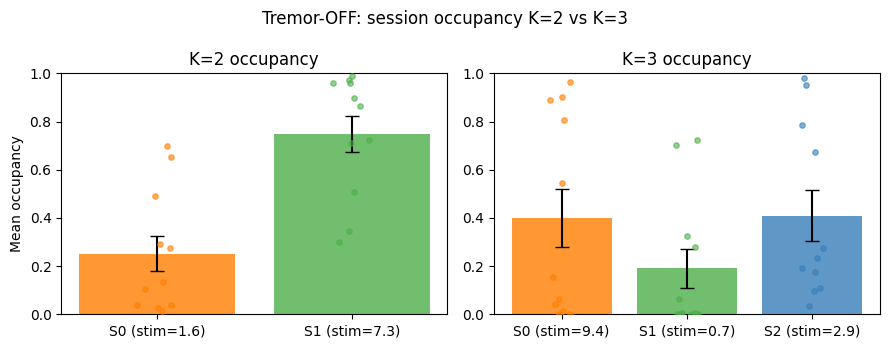


K=3 mean occupancy: [0.399 0.191 0.41 ] -> third state accounts for 41.0% of trials


In [11]:
# ── Per-session occupancy under K=2 and K=3 ──────────────────────────────────
occ2_list, occ3_list = [], []

for sid, df in data_toff.items():
    obs = df["choices"].values.astype(int).reshape(-1, 1)
    inp = df[FEATS].values.astype(float)
    msk = df["mask"].values.astype(bool).reshape(-1, 1)
    valid = msk[:, 0]

    # K=2 final model (per-session)
    m2 = toff_final["model"]["models"][sid]
    post2 = m2.expected_states(data=obs, input=inp, mask=msk)[0]
    sw2   = -m2.observations.params[:, 0, :]
    p2    = _align(sw2, w2)
    occ2_list.append(post2[:, p2][valid].mean(0))

    # K=3 best init pooled model (apply to each session)
    post3 = best_k3.expected_states(data=obs, input=inp, mask=msk)[0]
    sw3   = w3   # pooled weights, already (3, M)
    occ3_list.append(post3[valid].mean(0))

occ2 = np.array(occ2_list)   # (n_sessions, 2)
occ3 = np.array(occ3_list)   # (n_sessions, 3)

fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
for k in range(2):
    axes[0].bar(k, occ2[:, k].mean(), color=colors2[k], alpha=0.8,
                yerr=occ2[:, k].std()/np.sqrt(len(occ2)), capsize=5)
    axes[0].scatter(np.full(len(occ2), k) + np.random.uniform(-0.1,0.1,len(occ2)),
                    occ2[:,k], color=colors2[k], s=15, alpha=0.6, zorder=3)
axes[0].set_xticks(range(2)); axes[0].set_xticklabels([f"S{k} (stim={w2[k,STIM_IDX]:.1f})" for k in range(2)])
axes[0].set(ylabel="Mean occupancy", ylim=(0,1), title="K=2 occupancy")

for k in range(3):
    axes[1].bar(k, occ3[:, k].mean(), color=colors3[k], alpha=0.8,
                yerr=occ3[:, k].std()/np.sqrt(len(occ3)), capsize=5)
    axes[1].scatter(np.full(len(occ3), k) + np.random.uniform(-0.1,0.1,len(occ3)),
                    occ3[:,k], color=colors3[k], s=15, alpha=0.6, zorder=3)
axes[1].set_xticks(range(3)); axes[1].set_xticklabels([f"S{k} (stim={w3[k,STIM_IDX]:.1f})" for k in range(3)])
axes[1].set(ylim=(0,1), title="K=3 occupancy")

fig.suptitle("Tremor-OFF: session occupancy K=2 vs K=3", fontsize=12)
plt.tight_layout(); plt.show()

print("\nK=3 mean occupancy:", np.round(occ3.mean(0), 3),
      "-> third state accounts for", f"{occ3[:,2].mean():.1%} of trials")

## 2. Derived scalars: group-invariant metrics

These three scalars are computable from any GLM-HMM regardless of K:

| Scalar | Formula | Interpretation |
|---|---|---|
| `lapse_occ` | Σ_k occ_k · I(stim_w_k < threshold) | Fraction of trials in low-engagement states |
| `prior_sens` | Σ_k occ_k · color_w_k | Effective color-prior weight (signed) |
| `stim_sens` | Σ_k occ_k · stim_w_k | Effective stimulus sensitivity |

Using `LAPSE_THRESHOLD = 2.0` based on the weight distributions above
(clear gap between lapse states ≈0.3–1.6 and engaged states ≈2.3–8.1).

In [12]:
def compute_scalars(session_weights, session_occupancy):
    """Return (lapse_occ, prior_sens, stim_sens) for one session."""
    w   = session_weights    # (K, M)
    occ = session_occupancy  # (K,)
    lapse_occ  = float(np.sum(occ * (w[:, STIM_IDX] < LAPSE_THRESHOLD)))
    prior_sens = float(np.sum(occ * w[:, COLOR_IDX]))
    stim_sens  = float(np.sum(occ * w[:, STIM_IDX]))
    return lapse_occ, prior_sens, stim_sens


rows = []
for group in GROUPS:
    bundle = load_final(group)
    ref_w  = -bundle["model"]["pooled"].observations.params[:, 0, :]  # (K, M)
    config = bundle["config"]

    for sid, df in bundle["data"].items():
        if sid not in sess_md.index:
            continue
        m    = bundle["model"]["models"][sid]
        sw   = -m.observations.params[:, 0, :]  # (K, M)
        perm = _align(sw, ref_w)
        sw_al = sw[perm]

        obs  = df["choices"].values.astype(int).reshape(-1, 1)
        inp  = df[config["model_features"]].values.astype(float)
        msk  = df["mask"].values.astype(bool).reshape(-1, 1)
        post = m.expected_states(data=obs, input=inp, mask=msk)[0]
        occ  = post[:, perm][msk[:, 0]].mean(0)

        lo, ps, ss = compute_scalars(sw_al, occ)
        info = sess_md.loc[sid]
        rows.append({
            "session_id":  sid,
            "group":       group,
            "subject_id":  info["subject_id"],
            "subtype":     info["subtype"],
            "medication":  info["medication"],
            "is_pd":       info["is_pd"],
            "lapse_occ":   lo,
            "prior_sens":  ps,
            "stim_sens":   ss,
            "best_k":      bundle["best_k"],
        })

scalar_sess = pd.DataFrame(rows)
# average across sessions within subject × group
scalar_subj = (
    scalar_sess
    .groupby(["subject_id", "group", "subtype", "medication", "is_pd"])
    [["lapse_occ", "prior_sens", "stim_sens"]]
    .mean()
    .reset_index()
)

# join UPDRS
updrs_by_sess = updrs_md.set_index("session_id")[["UPDRS","tremor_score",
                                                    "bradykinesia_score",
                                                    "UPDRS_improvement",
                                                    "tremor_improvement",
                                                    "bradykinesia_improvement"]]
scalar_sess = scalar_sess.join(updrs_by_sess, on="session_id")
# per-subject UPDRS: use OFF session value (or mean if multiple)
updrs_subj = (
    scalar_sess[scalar_sess["medication"].isin(["off", "none"])]
    .groupby("subject_id")[["UPDRS","tremor_score","bradykinesia_score",
                             "UPDRS_improvement","tremor_improvement",
                             "bradykinesia_improvement"]]
    .mean()
)
scalar_subj = scalar_subj.join(updrs_subj, on="subject_id")

print("Per-subject scalar table:", scalar_subj.shape)
print(scalar_subj.groupby("group")[["lapse_occ","prior_sens","stim_sens"]].mean().round(3))

Per-subject scalar table: (60, 14)
            lapse_occ  prior_sens  stim_sens
group                                       
Brady_OFF       0.061       0.125      3.368
Brady_ON        0.152       0.129      3.446
Tremor_OFF      0.225       0.025      4.877
Tremor_ON       0.237       0.343      3.930
asmHC           0.149       0.222      4.294


## 3. Four contrasts on derived scalars

Same design as notebook 6.04 but now using group-K-invariant scalars.
BH-FDR correction within each contrast across 3 metrics.

In [13]:
SCALARS = ["lapse_occ", "prior_sens", "stim_sens"]
SCALAR_LABELS = {
    "lapse_occ":  f"Lapse occupancy\n(stim_w < {LAPSE_THRESHOLD})",
    "prior_sens": "Prior sensitivity\n(Σ occ·color_w)",
    "stim_sens":  "Stim sensitivity\n(Σ occ·stim_w)",
}

# convenience group subsets
def gsel(group_str):
    return scalar_subj[scalar_subj["group"] == group_str]

hc         = gsel("asmHC")
tremor_off = gsel("Tremor_OFF")
brady_off  = gsel("Brady_OFF")
tremor_on  = gsel("Tremor_ON")
brady_on   = gsel("Brady_ON")

print("Group sizes:",
      {g: len(gsel(g)) for g in GROUPS})


def between(ga, gb, la, lb):
    rows = []
    for s in SCALARS:
        a, b = ga[s].dropna().values, gb[s].dropna().values
        _, p = mannwhitneyu(a, b, alternative="two-sided")
        rows.append({"scalar": s, "n_a": len(a), "n_b": len(b),
                     f"mean_{la}": a.mean(), f"mean_{lb}": b.mean(),
                     "delta": b.mean()-a.mean(), "p": p})
    df = pd.DataFrame(rows).set_index("scalar")
    _, df["p_fdr"], _, _ = multipletests(df["p"].values, method="fdr_bh")
    df["sig"] = df["p_fdr"] < 0.05
    return df, la, lb


def within(ga, gb, la="OFF", lb="ON"):
    """Paired Wilcoxon on matched subject_ids."""
    merged = pd.merge(ga[["subject_id"]+SCALARS], gb[["subject_id"]+SCALARS],
                      on="subject_id", suffixes=("_a", "_b")).dropna()
    rows = []
    for s in SCALARS:
        a = merged[f"{s}_a"].values
        b = merged[f"{s}_b"].values
        _, p = wilcoxon(a, b) if len(a) >= 3 else (np.nan, np.nan)
        rows.append({"scalar": s, "n": len(a),
                     f"mean_{la}": a.mean(), f"mean_{lb}": b.mean(),
                     "delta": b.mean()-a.mean(), "p": p})
    df = pd.DataFrame(rows).set_index("scalar")
    valid = df["p"].notna()
    _, p_fdr, _, _ = multipletests(df.loc[valid, "p"].values, method="fdr_bh")
    df["p_fdr"] = np.nan
    df.loc[valid, "p_fdr"] = p_fdr
    df["sig"] = df["p_fdr"] < 0.05
    return df, la, lb


c1, la1, lb1 = between(hc,        pd.concat([tremor_off, brady_off]), "HC",       "PD_OFF")
c2, la2, lb2 = between(tremor_off, brady_off,                         "Tremor_OFF", "Brady_OFF")
c3, la3, lb3 = within( tremor_off, tremor_on,                         "Tremor_OFF", "Tremor_ON")
c4, la4, lb4 = within( brady_off,  brady_on,                          "Brady_OFF",  "Brady_ON")

print("\n--- Contrast 1: HC vs PD-OFF ---")
print(c1[["n_a","n_b","mean_HC","mean_PD_OFF","delta","p","p_fdr","sig"]].round(4))
print("\n--- Contrast 2: Tremor-OFF vs Brady-OFF ---")
print(c2[["n_a","n_b","mean_Tremor_OFF","mean_Brady_OFF","delta","p","p_fdr","sig"]].round(4))
print("\n--- Contrast 3: Tremor OFF→ON ---")
print(c3[["n","mean_Tremor_OFF","mean_Tremor_ON","delta","p","p_fdr","sig"]].round(4))
print("\n--- Contrast 4: Brady OFF→ON ---")
print(c4[["n","mean_Brady_OFF","mean_Brady_ON","delta","p","p_fdr","sig"]].round(4))

Group sizes: {'asmHC': 18, 'Tremor_OFF': 11, 'Brady_OFF': 10, 'Tremor_ON': 11, 'Brady_ON': 10}

--- Contrast 1: HC vs PD-OFF ---
            n_a  n_b  mean_HC  mean_PD_OFF   delta       p   p_fdr    sig
scalar                                                                   
lapse_occ    18   21   0.1486       0.1473 -0.0013  0.0446  0.0669  False
prior_sens   18   21   0.2219       0.0726 -0.1493  0.0384  0.0669  False
stim_sens    18   21   4.2938       4.1586 -0.1352  0.3453  0.3453  False

--- Contrast 2: Tremor-OFF vs Brady-OFF ---
            n_a  n_b  mean_Tremor_OFF  mean_Brady_OFF   delta       p   p_fdr  \
scalar                                                                          
lapse_occ    11   10           0.2253          0.0614 -0.1639  0.0438  0.1315   
prior_sens   11   10           0.0249          0.1251  0.1002  0.4181  0.5495   
stim_sens    11   10           4.8771          3.3682 -1.5089  0.5495  0.5495   

              sig  
scalar             
lapse_occ 

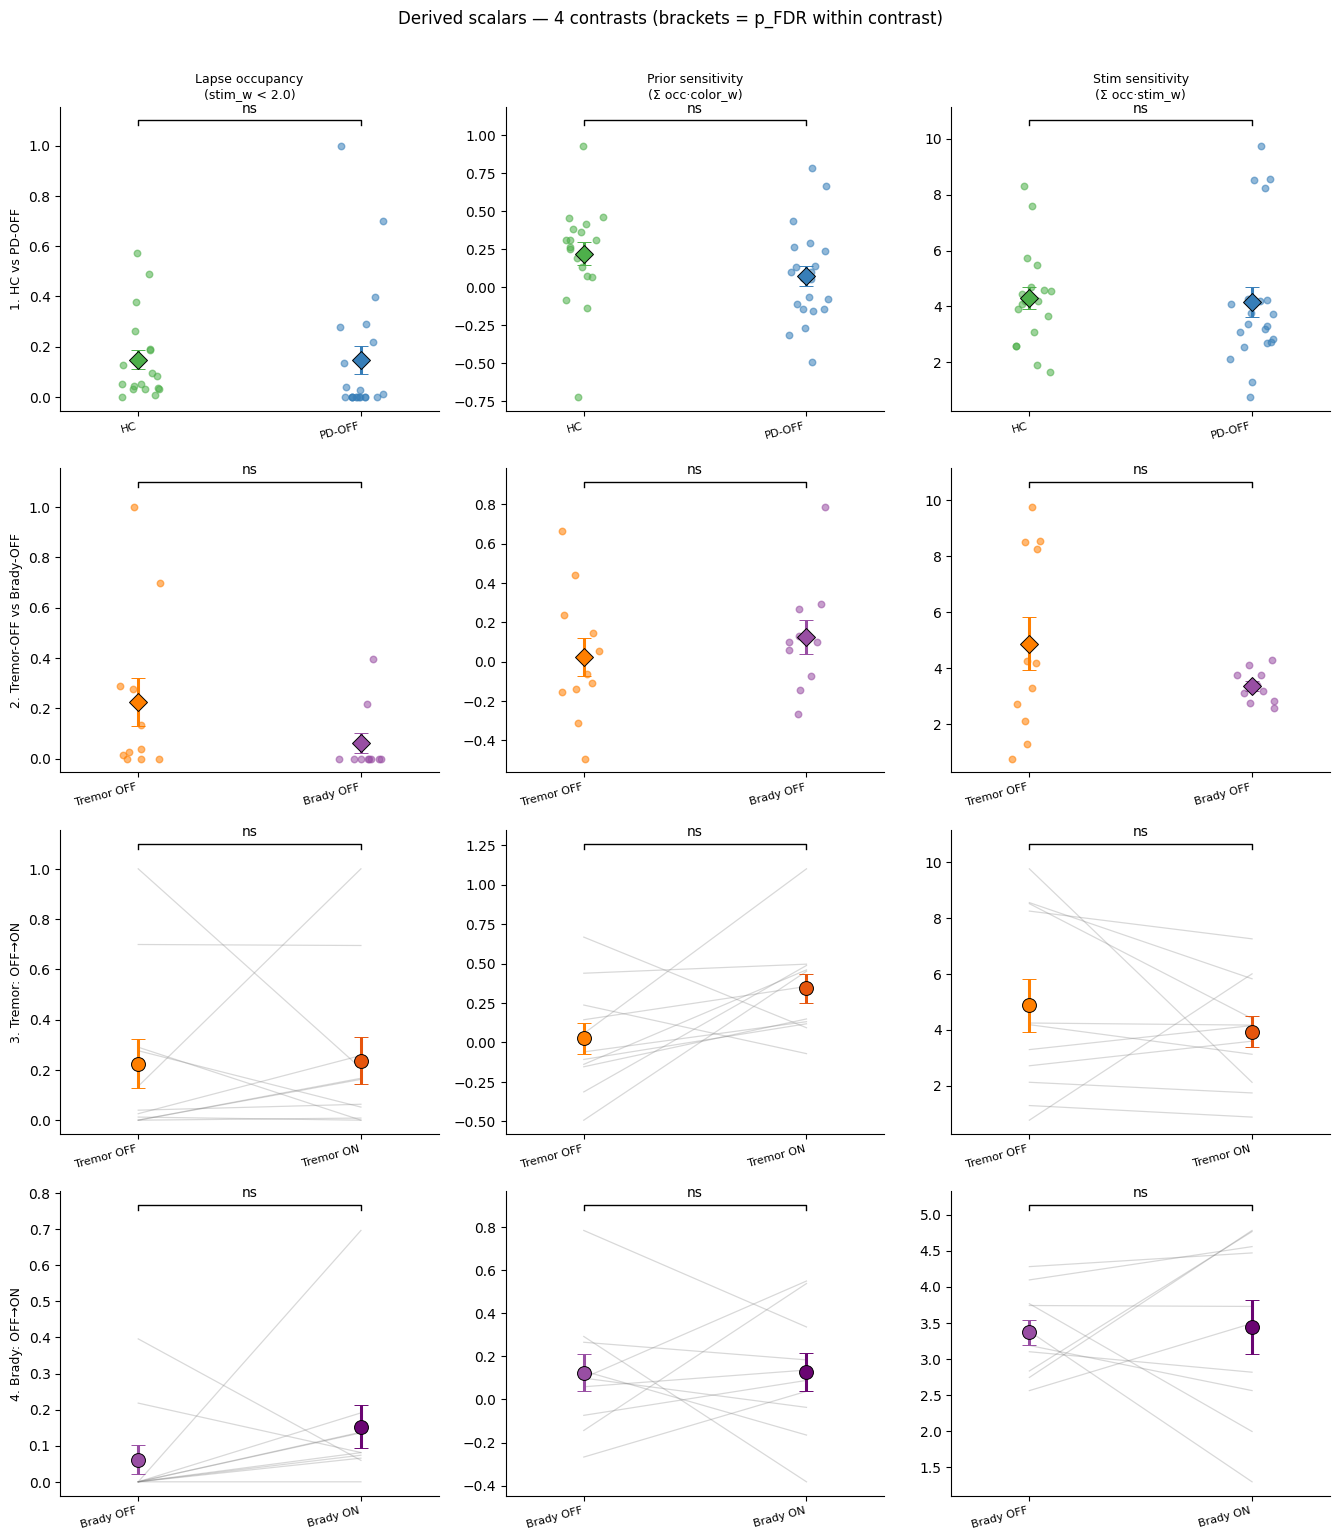

In [14]:
## Summary figure — 4 contrasts × 3 scalars

def sig_label(p):
    if pd.isna(p): return ""
    if p < 0.001:  return "***"
    if p < 0.01:   return "**"
    if p < 0.05:   return "*"
    return "ns"


CONTRAST_SPEC = [
    (c1, hc,         pd.concat([tremor_off, brady_off]), "HC",         "PD-OFF",    "#4daf4a", "#377eb8", "between", None),
    (c2, tremor_off, brady_off,                          "Tremor OFF", "Brady OFF", "#ff7f00", "#984ea3", "between", None),
    (c3, tremor_off, tremor_on,                          "Tremor OFF", "Tremor ON", "#ff7f00", "#e6550d", "within",  None),
    (c4, brady_off,  brady_on,                           "Brady OFF",  "Brady ON",  "#984ea3", "#6a0572", "within",  None),
]
CONTRAST_TITLES = [
    "1. HC vs PD-OFF",
    "2. Tremor-OFF vs Brady-OFF",
    "3. Tremor: OFF→ON",
    "4. Brady: OFF→ON",
]

nC, nS = 4, len(SCALARS)
fig, axes = plt.subplots(nC, nS, figsize=(4.5*nS, 3.8*nC), squeeze=False)

for ri, (res_df, ga, gb, la, lb, ca, cb, ttype, _) in enumerate(CONTRAST_SPEC):
    for ci, scalar in enumerate(SCALARS):
        ax = axes[ri][ci]

        if ttype == "between":
            a_vals = ga[scalar].dropna().values
            b_vals = gb[scalar].dropna().values
            for xpos, vals, color in [(0, a_vals, ca), (1, b_vals, cb)]:
                jit = np.random.uniform(-0.1, 0.1, len(vals))
                ax.scatter(xpos+jit, vals, color=color, s=22, alpha=0.55, zorder=3)
                ax.errorbar(xpos, vals.mean(), yerr=vals.std()/np.sqrt(len(vals)),
                            color=color, marker="D", ms=9, mec="k", mew=0.7,
                            capsize=5, lw=2.2, zorder=5)
        else:
            merged = pd.merge(ga[["subject_id", scalar]],
                              gb[["subject_id", scalar]],
                              on="subject_id", suffixes=("_a","_b")).dropna()
            a_vals = merged[f"{scalar}_a"].values
            b_vals = merged[f"{scalar}_b"].values
            for av, bv in zip(a_vals, b_vals):
                ax.plot([0,1], [av, bv], "-", color="gray", alpha=0.3, lw=0.9)
            for xpos, vals, color in [(0, a_vals, ca), (1, b_vals, cb)]:
                ax.errorbar(xpos, vals.mean(), yerr=vals.std()/np.sqrt(len(vals)),
                            color=color, marker="o", ms=10, mec="k", mew=0.7,
                            capsize=5, lw=2.2, zorder=5)

        p_fdr = res_df.loc[scalar, "p_fdr"] if scalar in res_df.index else np.nan
        slabel = sig_label(p_fdr)
        all_v = np.concatenate([a_vals, b_vals])
        ymax, ymin = all_v.max(), all_v.min()
        yr = max(ymax-ymin, 0.01)
        ytop = ymax + 0.08*yr
        ax.plot([0,0,1,1], [ytop, ytop+0.02*yr, ytop+0.02*yr, ytop], lw=1, color="k")
        ax.text(0.5, ytop+0.04*yr, slabel, ha="center", va="bottom", fontsize=10)

        ax.set_xticks([0,1])
        ax.set_xticklabels([la, lb], fontsize=8, rotation=15, ha="right")
        ax.set_xlim(-0.35, 1.35)
        ax.spines[["top","right"]].set_visible(False)
        if ci == 0:
            ax.set_ylabel(CONTRAST_TITLES[ri], fontsize=9)
        if ri == 0:
            ax.set_title(SCALAR_LABELS[scalar], fontsize=9)

fig.suptitle("Derived scalars — 4 contrasts (brackets = p_FDR within contrast)",
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

## 4. UPDRS correlation (PD-OFF subjects)

Spearman correlations between each scalar and UPDRS total / subscores.
Using OFF-medication sessions to reflect baseline severity.

In [15]:
pd_off_subj = scalar_subj[
    (scalar_subj["is_pd"] == 1) & (scalar_subj["medication"] == "off")
].dropna(subset=["UPDRS"])

UPDRS_COLS   = ["UPDRS", "tremor_score", "bradykinesia_score"]
UPDRS_LABELS = {"UPDRS": "UPDRS total", "tremor_score": "Tremor subscore",
                "bradykinesia_score": "Bradykinesia subscore"}

corr_rows = []
for scalar in SCALARS:
    for ucol in UPDRS_COLS:
        sub = pd_off_subj[[scalar, ucol]].dropna()
        r, p = spearmanr(sub[scalar], sub[ucol])
        corr_rows.append({"scalar": scalar, "updrs": ucol, "n": len(sub),
                          "rho": r, "p": p})

corr_df = pd.DataFrame(corr_rows)
_, corr_df["p_fdr"], _, _ = multipletests(corr_df["p"].values, method="fdr_bh")
corr_df["sig"] = corr_df["p_fdr"] < 0.05

print(f"UPDRS correlations (PD-OFF, n={len(pd_off_subj)}, Spearman, BH-FDR across all tests)")
corr_df.set_index(["scalar","updrs"])[["n","rho","p","p_fdr","sig"]].round(4)

UPDRS correlations (PD-OFF, n=21, Spearman, BH-FDR across all tests)


n     rho       p   p_fdr    sig
scalar     updrs                                                
lapse_occ  UPDRS               21 -0.2406  0.2935  0.4402  False
           tremor_score        21  0.2135  0.3528  0.4536  False
           bradykinesia_score  21 -0.3259  0.1494  0.4402  False
prior_sens UPDRS               21 -0.2651  0.2456  0.4402  False
           tremor_score        21 -0.4253  0.0546  0.4402  False
           bradykinesia_score  21 -0.2464  0.2816  0.4402  False
stim_sens  UPDRS               21  0.1035  0.6551  0.7370  False
           tremor_score        21  0.3549  0.1145  0.4402  False
           bradykinesia_score  21 -0.0215  0.9264  0.9264  False

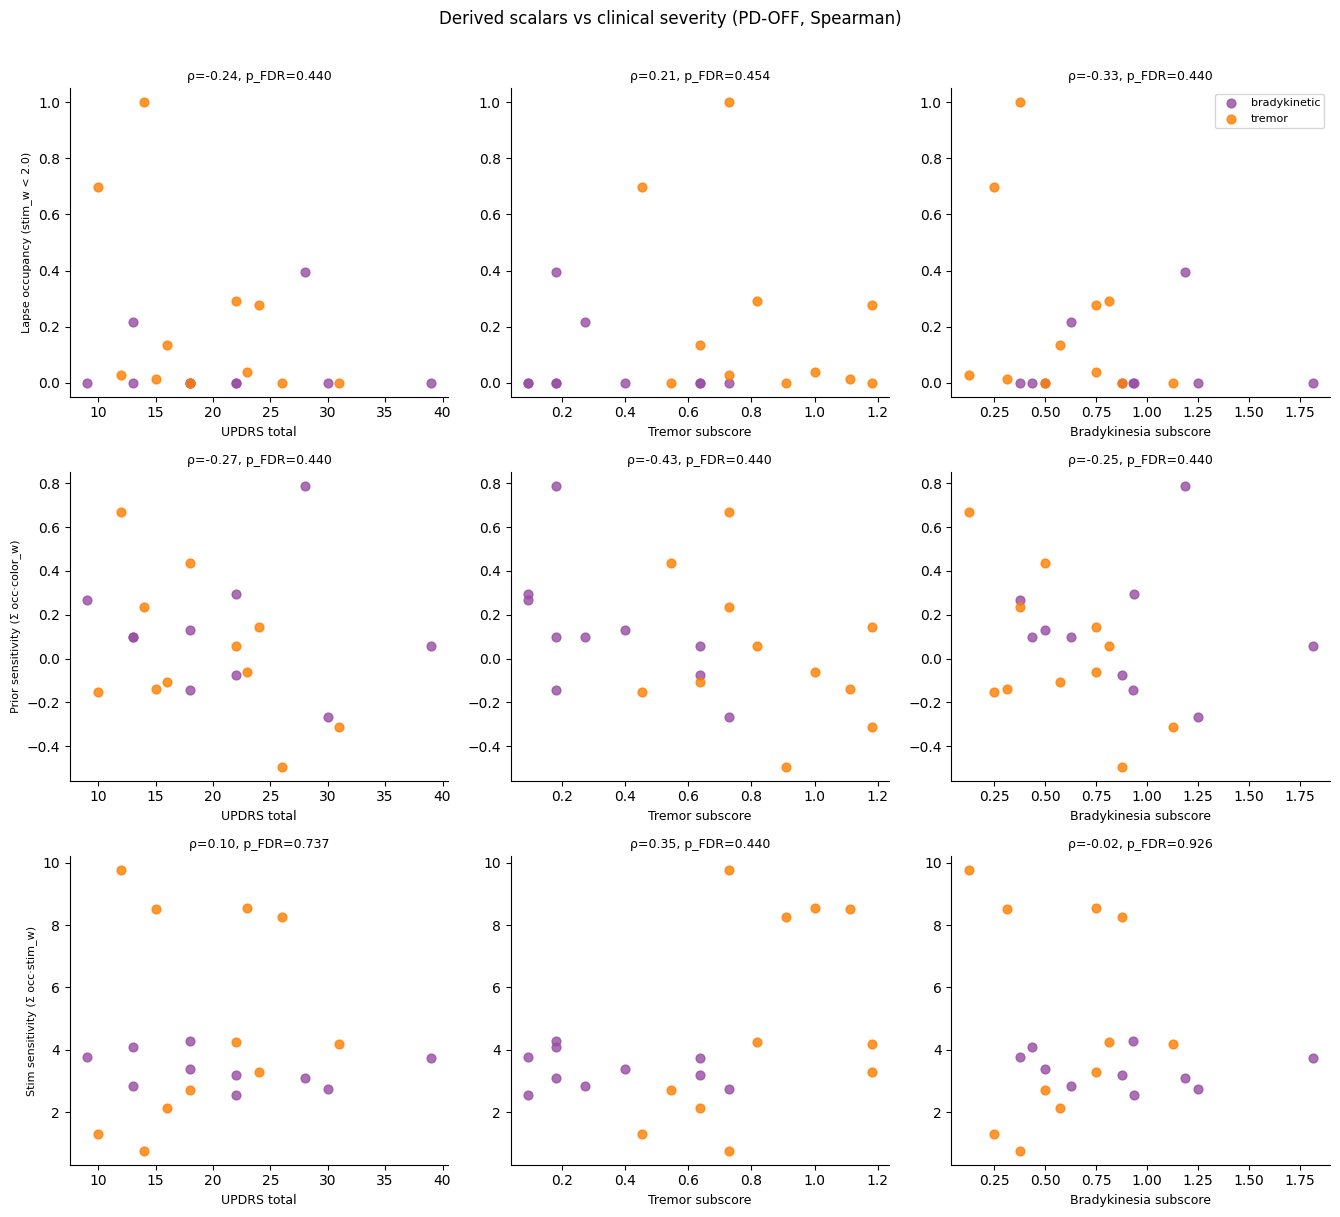

In [16]:
# Scatter plots: each scalar vs UPDRS scores
fig, axes = plt.subplots(len(SCALARS), len(UPDRS_COLS),
                         figsize=(4.5*len(UPDRS_COLS), 4.0*len(SCALARS)),
                         squeeze=False)

subtype_color = {"tremor": "#ff7f00", "bradykinetic": "#984ea3"}

for ri, scalar in enumerate(SCALARS):
    for ci, ucol in enumerate(UPDRS_COLS):
        ax = axes[ri][ci]
        sub = pd_off_subj[[scalar, ucol, "subtype"]].dropna()
        for stype, grp in sub.groupby("subtype"):
            col = subtype_color.get(stype, "gray")
            ax.scatter(grp[ucol], grp[scalar], color=col, s=40, alpha=0.8,
                       label=stype, zorder=3)

        row = corr_df[(corr_df["scalar"]==scalar) & (corr_df["updrs"]==ucol)].iloc[0]
        ptxt = f"p_FDR={row['p_fdr']:.3f}" + (" *" if row["sig"] else "")
        ax.set_title(f"ρ={row['rho']:.2f}, {ptxt}", fontsize=9)

        ax.set_xlabel(UPDRS_LABELS[ucol], fontsize=9)
        if ci == 0:
            ax.set_ylabel(SCALAR_LABELS[scalar].replace("\n"," "), fontsize=8)
        ax.spines[["top","right"]].set_visible(False)
        if ri == 0 and ci == len(UPDRS_COLS)-1:
            ax.legend(fontsize=8)

fig.suptitle("Derived scalars vs clinical severity (PD-OFF, Spearman)",
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

## 5. Medication effect scalars vs UPDRS improvement

For subjects with both OFF and ON sessions: does the *change* in each scalar
correlate with the clinical response to medication (UPDRS_improvement)?

In [17]:
# Build per-subject delta (ON - OFF) for each scalar
pd_off_df = scalar_subj[(scalar_subj["is_pd"]==1) & (scalar_subj["medication"]=="off")]
pd_on_df  = scalar_subj[(scalar_subj["is_pd"]==1) & (scalar_subj["medication"]=="on")]

delta = pd.merge(
    pd_off_df[["subject_id","subtype"]+SCALARS+["UPDRS_improvement","tremor_improvement","bradykinesia_improvement"]],
    pd_on_df[["subject_id"]+SCALARS],
    on="subject_id", suffixes=("_off","_on")
).dropna(subset=["UPDRS_improvement"])

for s in SCALARS:
    delta[f"delta_{s}"] = delta[f"{s}_on"] - delta[f"{s}_off"]

DELTA_SCALARS = [f"delta_{s}" for s in SCALARS]
IMP_COLS = ["UPDRS_improvement", "tremor_improvement", "bradykinesia_improvement"]

delta_corr_rows = []
for ds in DELTA_SCALARS:
    for ic in IMP_COLS:
        sub = delta[[ds, ic]].dropna()
        r, p = spearmanr(sub[ds], sub[ic])
        delta_corr_rows.append({"delta_scalar": ds, "improvement": ic,
                                 "n": len(sub), "rho": r, "p": p})

delta_corr = pd.DataFrame(delta_corr_rows)
_, delta_corr["p_fdr"], _, _ = multipletests(delta_corr["p"].values, method="fdr_bh")
delta_corr["sig"] = delta_corr["p_fdr"] < 0.05

print(f"Medication-effect scalars vs UPDRS improvement (n={len(delta)}, Spearman, BH-FDR)")
delta_corr.set_index(["delta_scalar","improvement"])[["n","rho","p","p_fdr","sig"]].round(4)

Medication-effect scalars vs UPDRS improvement (n=21, Spearman, BH-FDR)


n     rho       p   p_fdr    sig
delta_scalar     improvement                                                
delta_lapse_occ  UPDRS_improvement         21 -0.3941  0.0771  0.4180  False
                 tremor_improvement        21 -0.2466  0.2812  0.5295  False
                 bradykinesia_improvement  21 -0.2189  0.3404  0.5295  False
delta_prior_sens UPDRS_improvement         21 -0.1665  0.4707  0.5295  False
                 tremor_improvement        21 -0.2147  0.3500  0.5295  False
                 bradykinesia_improvement  21 -0.1689  0.4643  0.5295  False
delta_stim_sens  UPDRS_improvement         21  0.1808  0.4328  0.5295  False
                 tremor_improvement        21  0.0839  0.7176  0.7176  False
                 bradykinesia_improvement  21  0.3761  0.0929  0.4180  False